In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import confusion_matrix

def fit_bootstrap(y, X, X_test, n_boot = 200, residual_boot = False, boot_sample_ratio = 1):
    '''Function for fittting the model and bootstrap 
    Parameters:
    ---------------
    fit_predict: function for fitting and predicting by taking in y, X, X_test
    X: matrix of features
    y: vector of outcomes
    
    Return:
    --------------
    a tuple contains:
        predicted mean on the full data, numpy array of (X_test.shape[0],)
        se for the predicted mean on the full data: basically tau_n*se that shrinks as sample size increases, numpy array of (X_test.shape[0],)
        a matrix containing the bootstraped predicted mean, with rows indicting the sample index, 
        the columns indicating the bootstrap index, numpy array of (n_boot, X_test.shape[0])
    '''
    mean_boot_l = []
    for i in range(n_boot):
        index_boot= np.random.randint(X.shape[0], size=int(X.shape[0]*boot_sample_ratio))
        if residual_boot:
            residuals = y - mean_train
            y_boot = mean_train + residuals[index_boot]
            X_boot = X
        else:
            #import pdb;pdb.set_trace()
            y_boot = y[index_boot]
            X_boot = X[index_boot]
        mean_boot_l.append(LogisticRegression(solver = 'liblinear').fit(X_boot, y_boot).predict_proba(X_test)[:,1] )
    mean_boot_l = np.array(mean_boot_l)
    mean = LogisticRegression(solver = 'liblinear').fit(X, y).predict_proba(X_test)[:,1]
    se = np.std(mean_boot_l, axis = 0)
    return mean, se, mean_boot_l

# Breast Cancer dataset

In [117]:
bc_data = pd.read_csv('../data/breast_cancer.csv')
bc_data = bc_data.drop(columns = 'Unnamed: 32')
X = bc_data.drop(columns = 'diagnosis').to_numpy()
le = LabelEncoder()
y = le.fit_transform(bc_data['diagnosis'])

In [118]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    bc_data.drop('diagnosis', axis=1),
    bc_data['diagnosis'],
    test_size=0.2,
    random_state=42,
    stratify = bc_data['diagnosis']
)
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

In [119]:
# Bootstrap

In [120]:
clf = LogisticRegression().fit(X_train_std,y_train)
clf.predict_proba(X_test_std)[:,1]>0.7


array([False,  True, False, False, False, False,  True, False, False,
       False,  True, False,  True, False, False, False, False, False,
       False, False, False, False,  True,  True,  True, False, False,
        True,  True,  True,  True, False,  True,  True, False, False,
       False, False,  True, False, False, False,  True, False, False,
        True, False,  True, False, False,  True,  True, False, False,
       False,  True, False, False, False,  True, False, False,  True,
       False, False, False,  True,  True, False,  True, False,  True,
        True, False, False, False, False,  True, False,  True,  True,
        True, False, False, False, False,  True, False,  True, False,
        True, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False,  True, False,
        True, False, False, False, False,  True])

In [121]:
np.mean(y_test[clf.predict_proba(X_test_std)[:,1]>0.98]=='M')

1.0

# Obsestiy

In [149]:
obs_data = pd.read_csv('../data/ObesityDataSet_raw_and_data_sinthetic.csv')
obs_data['obesity'] = np.where(np.logical_or(np.logical_or(np.logical_or(obs_data.NObeyesdad ==  'Normal_Weight',
                               obs_data.NObeyesdad ==  'Insufficient_Weight'),
                               obs_data.NObeyesdad ==  'Overweight_Level_I'),
                               obs_data.NObeyesdad ==  'Overweight_Level_II'),
                               0,1
                              )
obs_data.drop(columns = 'NObeyesdad', inplace = True)
obs_data = pd.get_dummies(obs_data, drop_first = True)
# X = bc_data.drop(columns = 'diagnosis').to_numpy()
# le = LabelEncoder()
# y = le.fit_transform(bc_data['diagnosis'])

In [150]:
obs_data.columns

Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE',
       'obesity', 'Gender_Male', 'family_history_with_overweight_yes',
       'FAVC_yes', 'CAEC_Frequently', 'CAEC_Sometimes', 'CAEC_no', 'SMOKE_yes',
       'SCC_yes', 'CALC_Frequently', 'CALC_Sometimes', 'CALC_no',
       'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation',
       'MTRANS_Walking'],
      dtype='object')

In [151]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    obs_data.drop('obesity', axis=1),
    obs_data['obesity'],
    test_size=0.2,
    random_state=42,
    stratify = obs_data['obesity']
)
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

In [156]:
clf = LogisticRegression().fit(X_train_std,y_train)
np.mean(clf.predict(X_test_std)==y_test)

0.9905437352245863

In [162]:
np.mean(y_test[clf.predict_proba(X_test_std)[:,1]>0.1] ==1)

0.8904109589041096

# Myocardial infarction complications

In [329]:
MI_data = pd.read_csv('../data/Myocardial infarction complications Database.csv')
# Drop missingness that are greater than 0.5
MI_data['FIBR_ZSN'] = np.where(np.logical_or(MI_data.FIBR_PREDS==1, MI_data.ZSN==1), 1, 0)
c_outcome_index = [0]
c_outcome_index.extend(range(112,124))

In [330]:
MI_data.drop(MI_data.columns[c_outcome_index],axis = 1,inplace = True)
MI_data.drop(columns = MI_data.isnull().sum()[MI_data.isnull().sum()/len(MI_data)>0.5].index.to_list(), inplace = True)

In [331]:
imputer = KNNImputer(n_neighbors = 2)
X = imputer.fit_transform(MI_data.drop('FIBR_ZSN',axis=1))
y = MI_data['FIBR_ZSN'].to_numpy()

In [535]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify = y
)
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

In [536]:
mean, se, mean_boot_l = fit_bootstrap(y_train, X_train_std, X_test_std, n_boot = 500, residual_boot = False, boot_sample_ratio = 1)

In [618]:
import sys
sys.path.append('../functions')
import confidence_set_func
level = 0.6
G, mean, se =confidence_set_func.process_boot_samples(mean_boot_l, mean, se, None, 
                                      False, second_stage=False, center_G = True, center_pred = False)
dict_, L, U, _, _, _ = confidence_set_func.prediction_confidence_set(0.9, level, mean, se, G, mean_test_true = None, use_true_contour = False)

In [628]:
# Inner set
print(np.mean(y_test[dict_[dict_['inner']].index]))
print(len(y_test[dict_[dict_['inner']].index]))

0.8
5


In [627]:
# Inner set directly using point prediction
print(len(y_test[mean>level]))
print(np.mean(y_test[mean>level] ==1))

73
0.547945205479452


In [626]:
# Outside of outer set
print(np.mean(y_test[dict_[~dict_['outer']].index]))
print(len(y_test[dict_[~dict_['outer']].index]))

0.18023255813953487
344


In [623]:
# using point prediction outside of outer
print(len(y_test[mean<level]))
print(np.mean(y_test[mean<level] ==1))

607
0.26688632619439867


# California Housing

In [471]:
import numpy as np 
import pandas as pd 
#import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline

#ignoring the warnings while executing codes
import warnings
warnings.filterwarnings("ignore")

# importing custom matplotlib parameters for vizualizations
plt.rcParams['figure.figsize'] = (14,4)
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['figure.frameon'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams["font.family"] = "monospace";

# Color Palettes
colors = ["#bfd3e6", "#9b5b4f", "#4e4151", "#dbba78", "#bb9c55", "#909195","#dc1e1e","#a02933","#716807","#717cb4"]
#importing Dataset
house = pd.read_csv("../data/house-prices-advanced-regression-techniques/train.csv")
house_test = pd.read_csv("../data/house-prices-advanced-regression-techniques/test.csv")


In [472]:
house.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


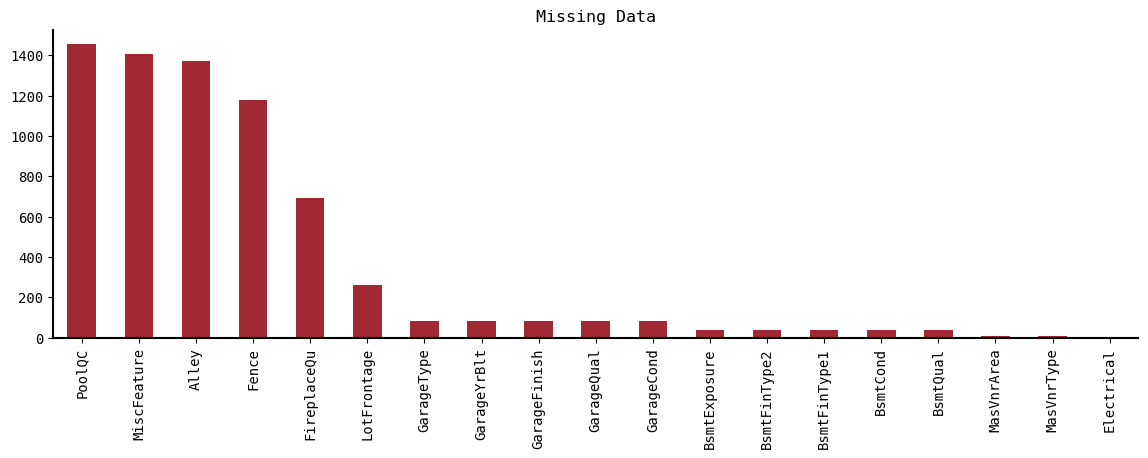

In [473]:
#checking missing values
missing = house.isnull().sum()
missing = missing[missing > 0]
missing = missing.sort_values(ascending = False)
missing.plot.bar(color=colors[7])
plt.title('Missing Data');

In [474]:
# droping values more than 50%

Y = house['SalePrice']
#y_test = house_test['SalePrice']
house = house.drop(['Id','Alley','PoolQC','Fence','MiscFeature','SalePrice'],axis=1)
house_test = house_test.drop(['Id','Alley','PoolQC','Fence','MiscFeature'],axis=1)


In [475]:
house_test.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF'

In [476]:
print(y_test.shape)
print(house_test.shape)

(438,)
(1459, 75)


In [477]:
num_cols = [col for col in house.columns if house[col].dtype in ['float64','int64']]
cat_cols = [col for col in house.columns if house[col].dtype not in ['float64','int64']]

In [478]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

house[num_cols] = SimpleImputer().fit_transform(house[num_cols])
house_test[num_cols] = SimpleImputer().fit_transform(house_test[num_cols])

house[num_cols] = MinMaxScaler().fit_transform(house[num_cols])
house_test[num_cols] = MinMaxScaler().fit_transform(house_test[num_cols])

In [479]:
columns_None = ['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','GarageType','GarageFinish','GarageQual','FireplaceQu','GarageCond',
                'MasVnrType','Electrical','MSZoning','Utilities','Functional','Exterior2nd','KitchenQual','Exterior1st','SaleType']
house[columns_None] = house[columns_None].fillna('none')
house_test[columns_None] = house_test[columns_None].fillna('none')


In [480]:
from sklearn.preprocessing import OneHotEncoder

# One-hot encode categorical columns
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore').fit(house[cat_cols])
encoded_cols = list(encoder.get_feature_names_out(cat_cols))
house[encoded_cols] = encoder.transform(house[cat_cols])
house_test[encoded_cols] = encoder.transform(house_test[cat_cols])


In [484]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
X_train_pd,X_test_pd,y_train_pd,y_test_pd = train_test_split(house[num_cols + encoded_cols+cat_cols],
                                                 y,
                                                 test_size=0.3,
                                                 random_state=42)


In [486]:
X_train = X_train_pd[num_cols + encoded_cols].to_numpy()
X_test = X_test_pd[num_cols + encoded_cols].to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [487]:
X_test.shape

(438, 287)

In [488]:
y_test.shape

(438,)

In [489]:
X_train.shape

(1022, 287)

In [490]:
y_train.shape

(1022,)

In [491]:
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [197]:
def fit_bootstrap(model, y, X, X_test, n_boot = 200, residual_boot = False, boot_sample_ratio = 1, **m_para):
    '''Function for fittting the model and bootstrap 
    Parameters:
    ---------------
    fit_predict: function for fitting and predicting by taking in y, X, X_test
    X: matrix of features
    y: vector of outcomes
    
    Return:
    --------------
    a tuple contains:
        predicted mean on the full data, numpy array of (X_test.shape[0],)
        se for the predicted mean on the full data: basically tau_n*se that shrinks as sample size increases, numpy array of (X_test.shape[0],)
        a matrix containing the bootstraped predicted mean, with rows indicting the sample index, 
        the columns indicating the bootstrap index, numpy array of (n_boot, X_test.shape[0])
    '''
    mean_boot_l = []
    mean_boot_y_l = []
    #import pdb; pdb.set_trace()
    #print(other['test'])
    for i in range(n_boot):
        index_boot= np.random.randint(X.shape[0], size=int(X.shape[0]*boot_sample_ratio))
        index_val = np.array(list(range(0,X.shape[0])))[~np.isin(list(range(0,X.shape[0])), index_boot)]
        if residual_boot:
            residuals = y - mean_train
            y_boot = mean_train + residuals[index_boot]
            X_boot = X
        else:
            #import pdb;pdb.set_trace()
            y_boot = y[index_boot]
            X_boot = X[index_boot]
            X_val = X[index_val]
            y_val = y[index_val]
        m = model(**m_para).fit(X_boot, y_boot)
        preds = m.predict(X_test)
        mean_boot_l.append(preds)
        err = m.predict(X_val)-y_val
        temp = preds + err[np.random.randint(0, len(err), size = (len(preds),) )]
        mean_boot_y_l.append(temp)
    mean_boot_l = np.array(mean_boot_l)
    mean_boot_y_l = np.array(mean_boot_y_l)
    mean = model(**m_para).fit(X, y).predict(X_test)
    se = np.std(mean_boot_l, axis = 0)
    se_y = np.std(mean_boot_y_l, axis = 0)
    return mean, se, mean_boot_l, se_y, mean_boot_y_l

In [520]:
mean, se, mean_boot_l, se_y, mean_boot_y_l = fit_bootstrap(RandomForestRegressor, y_train, X_train, X_test)


In [521]:
import sys
sys.path.append('../functions')
import confidence_set_func
level = np.median(mean)
G, mean, se =confidence_set_func.process_boot_samples(mean_boot_l, mean, se, None, 
                                      False, second_stage=False, center_G = True, center_pred = False)
dict_, L, U, _, _, _ = confidence_set_func.prediction_confidence_set(0.9, level, mean, se, G, mean_test_true = None, use_true_contour = False)

In [522]:
G_y, mean, se_y =confidence_set_func.process_boot_samples(mean_boot_y_l, mean, se_y, None, 
                                      False, second_stage=False, center_G = True, center_pred = False)
dict_y, L, U, contain, contain_scb, contain_CS_scb, L1, L2, U1, U2, n_points, range_v, inner_points_num,outer_points_num,true_set_points_num = confidence_set_func.prediction_confidence_set(0.9, level, mean, se_y, G_y, mean_test_true = y_test, use_true_contour = False)

In [539]:
print(level)

159475.26


In [523]:
contain_CS_scb

True

In [524]:
contain

True

In [545]:
pred_mean_set = y_test[mean>level]>level
print(len(pred_mean_set))
print(np.mean(pred_mean_set))

219
0.9223744292237442


In [540]:
true_mean_set = y_test[dict_['inner']]>level
print(len(true_mean_set))
print(np.mean(true_mean_set))

184
0.967391304347826


In [542]:
true_outcome_set = y_test[dict_y['inner']]>level
print(len(true_outcome_set))
print(np.mean(true_outcome_set))

23
1.0


In [527]:
y_test[dict_y['inner']]>level

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

## Interpretation

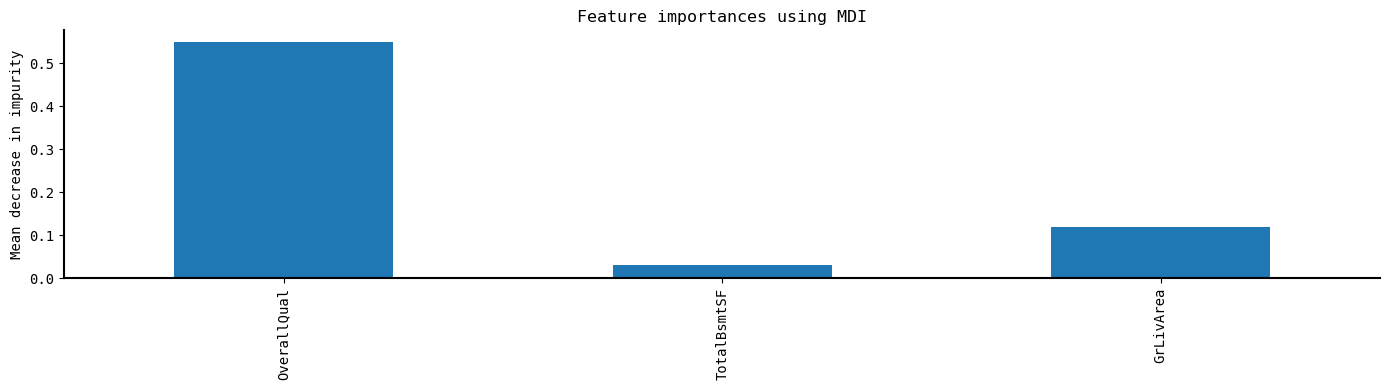

In [536]:
# random forest interpretation
rf = RandomForestRegressor().fit(X_train, y_train)
std = np.std([rf.feature_importances_ for tree in rf.estimators_], axis=0)
importances = rf.feature_importances_
feature_names = num_cols + encoded_cols
index_top = np.where( np.isin(importances,np.sort(importances)[-3:]))[0]
importances = importances[index_top]
feature_names = np.array(feature_names)[index_top]
std = std[index_top]

forest_importances = pd.Series(importances, index=feature_names)
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

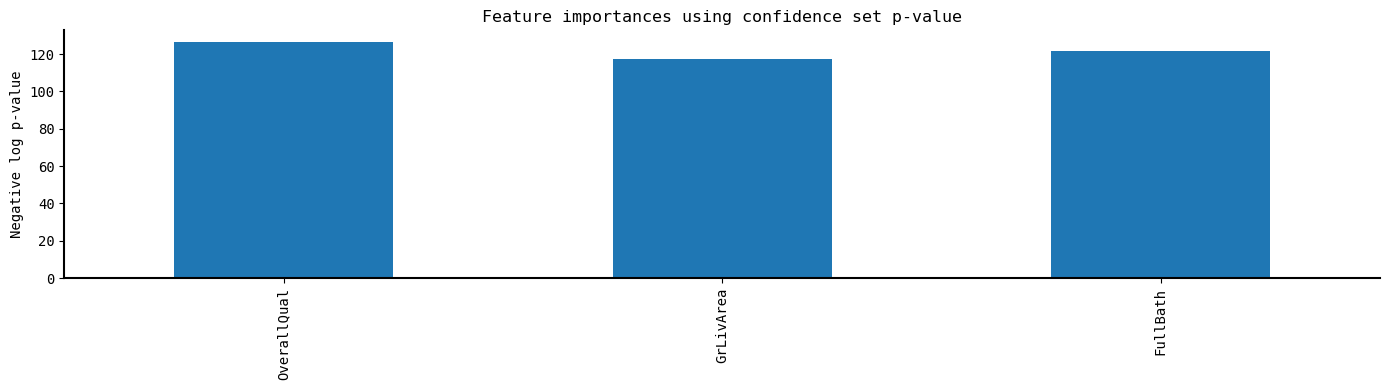

In [538]:
# Confidence set importatnce
from scipy import stats
def CS_t_test(inner_index, outer_index, X_test):
    n_inner = np.sum(inner_index)
    n_comp_outer = np.sum(~outer_index)
    p_values = []
    for j in range(X_test.shape[1]):
        x_j = X_test.iloc[:,j]
        if x_j.dtype not in ['float64','int64']:
            #import pdb; pdb.set_trace()
            temp1 = pd.concat([pd.Series(['inner']).repeat(len(x_j[inner_index])), pd.Series(['outer']).repeat(len(x_j[~outer_index]))] ).reset_index(drop = True)
            temp2 = pd.concat((x_j[inner_index],x_j[~outer_index])).reset_index(drop = True)
            temp = pd.concat( (temp2, temp1),axis = 1)
            tab = pd.crosstab(temp.iloc[:,1],temp.iloc[:,0])
            res = stats.chi2_contingency(tab)
            p_values.append(res[1])
        else:
            if len(np.unique(x_j))>2:
                p_values.append(stats.mannwhitneyu(x_j[inner_index], x_j[~outer_index])[1])
            else:# binomial two sample t-test
                p_values.append(stats.ttest_ind(x_j[inner_index], x_j[~outer_index])[1])
    return np.array(p_values)
    #import pdb; pdb.set_trace()
    # mean1 = np.mean(X_test[inner_index], axis = 0) 
    # mean2 = np.mean(X_test[~outer_index], axis = 0)
    # sd1 = np.std(X_test[inner_index], axis = 0)
    # sd2 = np.std(X_test[~outer_index], axis = 0)
    # var_mean1 = sd1**2/n_inner
    # var_mean2 = sd2**2/n_comp_outer
    # t = (mean1 - mean2 )/np.sqrt(var_mean1+var_mean2)
    # v = (var_mean1+var_mean2)**2/(var_mean1/(n_inner-1)+var_mean2/(n_comp_outer-1))
    # t_q = stats.t.ppf(0.975, v)
    #return stats.mannwhitneyu(X_test[inner_index], X_test[~outer_index])
p = CS_t_test(dict_['inner'], dict_['outer'], X_test_pd[num_cols+cat_cols].reset_index(drop = True))
index_top = np.where( np.isin(p,np.sort(p)[0:3]))[0]
significant_col = house[num_cols + cat_cols].columns[index_top]
#significant_col = np.unique([x.split('_')[0] for x in significant_col])
forest_importances = pd.Series(-np.log(p[index_top]), index=significant_col)
fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)
ax.set_title("Feature importances using confidence set p-value")
ax.set_ylabel("Negative log p-value")
fig.tight_layout()

In [501]:
np.sum(np.sum(X_test_pd[num_cols+cat_cols].reset_index(drop = True).isnull()))

0

In [495]:
X_test_pd.reset_index(drop = True)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,0.000000,0.167808,0.033252,0.555556,0.875,0.659420,0.883333,0.000000,0.117470,0.0,...,TA,Typ,none,Attchd,RFn,TA,TA,Y,WD,Normal
1,0.235294,0.263699,0.051209,0.777778,0.500,0.884058,0.750000,0.226250,0.182849,0.0,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
2,0.058824,0.119863,0.035804,0.444444,0.625,0.398551,0.000000,0.000000,0.000000,0.0,...,TA,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Normal
3,0.176471,0.099315,0.017294,0.555556,0.750,0.543478,0.000000,0.000000,0.070695,0.0,...,TA,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Normal
4,0.000000,0.232877,0.054210,0.888889,0.500,0.978261,0.966667,0.043750,0.181077,0.0,...,Ex,Typ,Ex,Attchd,Fin,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,0.000000,0.167808,0.032139,0.444444,0.625,0.623188,0.700000,0.000000,0.149894,0.0,...,TA,Typ,none,Attchd,RFn,TA,TA,Y,WD,Normal
434,0.000000,0.095890,0.021127,0.222222,0.875,0.601449,0.916667,0.000000,0.045358,0.0,...,TA,Typ,none,Attchd,Unf,Fa,TA,Y,WD,Normal
435,0.235294,0.150685,0.031901,0.666667,0.625,0.978261,0.950000,0.064803,0.000000,0.0,...,Gd,Typ,none,Attchd,RFn,TA,TA,Y,WD,Normal
436,0.176471,0.157534,0.051667,0.555556,0.875,0.347826,0.833333,0.000000,0.000000,0.0,...,Gd,Typ,none,Detchd,Unf,TA,TA,Y,ConLI,Normal


In [468]:
X_test[:,index_top][:,4]

array([0.33333333, 0.66666667, 0.33333333, 0.66666667, 0.66666667,
       0.33333333, 0.33333333, 0.66666667, 0.33333333, 0.33333333,
       0.66666667, 0.33333333, 0.33333333, 0.66666667, 0.66666667,
       0.33333333, 0.66666667, 0.33333333, 0.33333333, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.33333333, 0.66666667,
       0.66666667, 0.66666667, 0.33333333, 0.66666667, 0.66666667,
       0.33333333, 0.66666667, 1.        , 0.33333333, 0.66666667,
       0.33333333, 0.33333333, 0.66666667, 0.66666667, 0.33333333,
       0.33333333, 0.66666667, 0.33333333, 0.66666667, 0.33333333,
       0.66666667, 0.33333333, 0.33333333, 0.66666667, 0.33333333,
       0.33333333, 0.66666667, 0.33333333, 0.66666667, 0.33333333,
       0.66666667, 0.66666667, 0.66666667, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.33333333, 0.66666667, 0.33333333, 0.66666667,
       0.66666667, 0.33333333, 0.33333333, 0.66666667, 0.66666

In [414]:
# linear regression
import statsmodels.formula.api as smf
fit_data = pd.concat((Y, house[used_columns]), axis = 1)
formula = 'SalePrice ~' + '+'.join(used_columns)
formula ='SalePrice ~BedroomAbvGr+BldgType+BsmtCond+BsmtExposure+BsmtFinSF1+BsmtFinSF2+BsmtFinType1+BsmtFinType2+BsmtFullBath+BsmtQual+BsmtUnfSF+CentralAir+Condition1+Condition2+Electrical+EnclosedPorch+ExterCond+ExterQual+Exterior1st+Exterior2nd+FireplaceQu+Fireplaces+Foundation+FullBath+Functional+GarageArea+GarageCars+GarageCond+GarageFinish+GarageQual+GarageType+GarageYrBlt+GrLivArea+HalfBath+Heating+HeatingQC+HouseStyle+KitchenAbvGr+KitchenQual+LandContour+LotArea+LotFrontage+LotShape+MSZoning+MasVnrArea+MasVnrType+MiscVal+Neighborhood+OpenPorchSF+OverallCond+OverallQual+PavedDrive+SaleCondition+SaleType+ScreenPorch+TotRmsAbvGrd+TotalBsmtSF+WoodDeckSF+YearBuilt+YearRemodAdd'
model = smf.ols(formula = formula, data = fit_data).fit()
#model = sm.OLS(Y,X.data)
signi_linear=np.unique([x.split('[')[0] for x in list(model.pvalues.index[model.pvalues<0.05])])
np.isin(signi_linear, significant_col)